# Cox-BNN
## A Bayesian Neural Network for Sruvival Analysis

**Authors**: Alice Conighi, Emanuele Valea, Giovanni Zedda

<small>Final project for Probabilistic and Machine Learning course held by Prof. Luca Bortolussi at University of Trieste A.Y. 2025/2026.</small>


### Introduction

In this project we are going to do some experiments on a Bayesian Neural Network for survival data. With survival data we refer to time-to-event modelling, usually in presence of censoring, which means that not all instances are observed until the occurence of the event.

More formally, we deal with data $(T_i, \Delta_i)$, where $T_i=\min(Y_i, C_i)$, minimum between the real time-to-event $Y_i$ and time to censoring $C_i$, and $\Delta_i=I(Y_i\le C_i)$. Notice that $\Delta_i=0$ does not refer to a missing datum, because it conveys anyway the valuable information that subject $i$ was "alive" at least up to time $C_i$.

For a theoretical introduction to basic quantities and definitions in survival analysis, we point the `EDA_and_CoxModel.ipynb` file or even better to Klein and Moeschberger, 2003.

We use only a dataset for testing the methods we propose, but Lillelund, Magris and Pedersen 2024 show interesting results for a more variegate benchmark. The dataset we use comes from the National Institutes of Health and comprehends a list of 2139 subjects who are infected with HIV. The time-to-event here is the occurence an AIDS defining symptom or the halving of CD4 or both. Or death.

The censoring mechanism is a bit more complicated than raw right-censoring, however we stick to the latter. Censoring is also reasonably independent from the real time-to-event, since it is mostly a constant (Type 1 censoring, the end of study).


In [1]:
from ucimlrepo import list_available_datasets, fetch_ucirepo
list_available_datasets(search='AIDS')

-------------------------------------------------------------
The following datasets are available for search query "aids":
-------------------------------------------------------------
Dataset Name                            ID    
------------                            --    
AIDS Clinical Trials Group Study 175    890   



In [2]:
aids_clinical_trials_group = fetch_ucirepo(id=890) 
print(aids_clinical_trials_group.keys())

dict_keys(['data', 'metadata', 'variables'])


In [3]:
print(aids_clinical_trials_group.data['features'].keys())
print(aids_clinical_trials_group.data['targets'].keys())

Index(['time', 'trt', 'age', 'wtkg', 'hemo', 'homo', 'drugs', 'karnof',
       'oprior', 'z30', 'zprior', 'preanti', 'race', 'gender', 'str2', 'strat',
       'symptom', 'treat', 'offtrt', 'cd40', 'cd420', 'cd80', 'cd820'],
      dtype='str')
Index(['cid'], dtype='str')


### Exploratory Data Analysis and Preprocessing

In [149]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [150]:
aids: pd.DataFrame = pd.concat([
        aids_clinical_trials_group.data['features'], 
        aids_clinical_trials_group.data['targets']
    ], axis=1
)

In [151]:
pd.options.display.max_columns = None
display(aids.head())

,time,trt,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,zprior,preanti,race,gender,str2,strat,symptom,treat,offtrt,cd40,cd420,cd80,cd820,cid
0,948,2,48,89.8128,0,0,0,100,0,0,1,0,0,0,0,1,0,1,0,422,477,566,324,0
1,1002,3,61,49.4424,0,0,0,90,0,1,1,895,0,0,1,3,0,1,0,162,218,392,564,1
2,961,3,45,88.4520,0,1,1,90,0,1,1,707,0,1,1,3,0,1,1,326,274,2063,1893,0
3,1166,3,47,85.2768,0,1,0,100,0,1,1,1399,0,1,1,3,0,1,0,287,394,1590,966,0
4,1090,0,43,66.6792,0,1,0,100,0,1,1,1352,0,1,1,3,0,0,0,504,353,870,782,0


In [152]:
print('Total number of observations:', len(aids))
print(f"Total number of censored data: {aids.cid.sum()} ({100*aids.cid.mean():.2f}%)")

Total number of observations: 2139
Total number of censored data: 521 (24.36%)


In [153]:
aids.std()[aids.std()<0.2]

oprior    0.146629
zprior    0.000000
dtype: float64

Variable `zprior` show no variability in the dataset, hence we will remove it later.

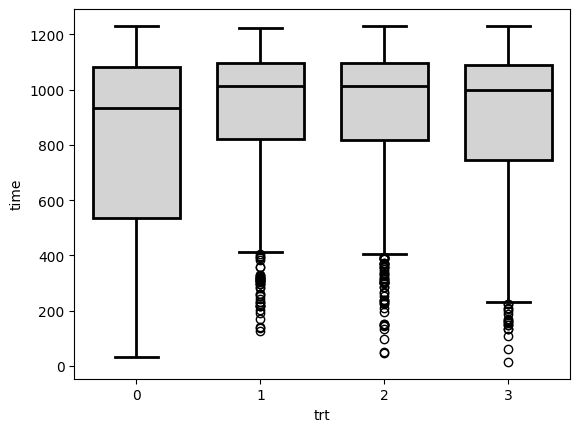

In [154]:
sns.boxplot(data=aids, x='trt', y='time', color='lightgrey', 
            linecolor='black', linewidth=2, width=0.7)#, ax=axes[0])
plt.show()

In [155]:
aids.groupby('strat')[['preanti']].mean()
# strat:
    # antiretroviral history stratification (1='Antiretroviral Naive',
    #                                        2='> 1 but <= 52 weeks of prior antiretroviral therapy',
    #                                        3='> 52 weeks)
# preanti:
    # days pre-175 anti-retroviral therapy

,preanti
strat,
1,0.081264
2,186.890244
3,871.126928


In [156]:
from collections import OrderedDict
from itertools import pairwise
from typing import Any, Callable, Sequence

import torch
import torch.nn as nn
import torch.nn.functional as F

In [157]:
class BayesianGaussianLinear(nn.Module):
    """
    Parameters: mu_w, rho_w (weights), mu_b, rho_b (biases).
    sigma = softplus(rho) ensures positivity without constraints.
    """
    def __init__(self, in_dim: int, out_dim: int, prior_sigma: float = 2.0):
        super().__init__()
        self.in_dim  = in_dim
        self.out_dim = out_dim
        self.prior_sigma  = prior_sigma

        kaiming_he_sigma = 4/(in_dim+out_dim)

        # Variational parameters for weights: shape (out, in)
        self.mu_w = nn.Parameter(torch.empty(out_dim, in_dim).normal_(0, kaiming_he_sigma))
        self.rho_w = nn.Parameter(torch.empty(out_dim, in_dim).fill_(-2.5))

        # Variational parameters for biases: shape (out,)
        self.mu_b = nn.Parameter(torch.empty(out_dim).normal_(0, 0.1))
        self.rho_b = nn.Parameter(torch.empty(out_dim).fill_(-2.5))


    def _sigma(self, rho: nn.Parameter):
        """Softplus riparametrization."""
        sigma = F.softplus(rho) + 1e-8
        return sigma


    def _kl_gaussian(self, mu: torch.Tensor, sigma: torch.Tensor) -> torch.Tensor:
        """KL Divergence (closed formula) between prior and 
        variational posterior with mean field assumption.
        """
        sigma0 = self.prior_sigma
        kl = (torch.log(sigma0/sigma) + (sigma**2 + mu**2) / (2*sigma0**2) - 1/2).sum()
        return kl
    

    def layer_kl(self) -> torch.Tensor:
        "Compute the KL regularization term for a single layer."
        # Softplus transformation
        sigma_w = self._sigma(self.rho_w) # (out, in)
        sigma_b = self._sigma(self.rho_b) # (out,)
        return(
            self._kl_gaussian(self.mu_w, sigma_w) 
            + self._kl_gaussian(self.mu_b, sigma_b)
        )


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x has size (B, nodes)

        # Softplus transformation
        sigma_w = self._sigma(self.rho_w) # (out, in)
        sigma_b = self._sigma(self.rho_b) # (out,)
        # Reparametrization
        eps_w = torch.randn_like(self.mu_w)
        eps_b = torch.randn_like(self.mu_b)
        W = sigma_w*eps_w + self.mu_w
        b  = sigma_b*eps_b + self.mu_b

        # Standard linear transformation
        out = x @ W.T + b

        # KL contribution from this layer
        # kl = self._kl_gaussian(self.mu_w, sigma_w) + self._kl_gaussian(self.mu_b, sigma_b)

        return out

In [158]:
class BayesianMLP(nn.Module):
    def __init__(self, *size: int, prior_sigma: float = 1.0):
        if len(size) < 1:
            raise ValueError('At least one size (input size) must be provided')
        super().__init__()
        self.size = size
        self.prior_sigma = prior_sigma
        self.net = self.__make_net()


    def __make_net(self) -> nn.Sequential:
        layers: list[tuple[str, nn.Module]] = []
        for k, (s_in, s_out) in enumerate(pairwise(self.size)):
            layers.append((f"l{k}", BayesianGaussianLinear(s_in, s_out, self.prior_sigma)))
            layers.append((f"h{k}", nn.Tanh()))
        layers.append(('out', BayesianGaussianLinear(self.size[-1], 1, self.prior_sigma)))
        return nn.Sequential(OrderedDict(layers))

    def network_kl(self) -> torch.Tensor:
        """Sum over all KL contributions in the layers."""
        kl = torch.tensor(0.0, dtype=torch.float)
        for layer in self.net:
            if hasattr(layer, 'layer_kl') and isinstance(layer.layer_kl, Callable):
                kl += layer.layer_kl()
        return kl

    def forward(self, x):
        return self.net(x)

In [159]:
def cox_partial_loglik(t: torch.Tensor, 
                       delta: torch.Tensor, 
                       loghr_hat: torch.Tensor) -> torch.Tensor:
    """Cox Partial Likelihood (the negative is a loss component)

    Parameters
    ----------
    t : Tensor[float]
        Time to event or censoring
    delta : Tensor[float]
        Indicator `1.0` is observed
    loghr_hat : Tensor[float]
        Output of the BNN
    
    All inputs must be reduced to size (BATCH_SIZE,).
    
    Returns
    -------
    ll : ScalarTensor
        The partial log-likelihood for a Cox proportional hazards model
        with Breslow tie-breaker.

        Sum_{i: delta_i==1} [h - log Sum_{j: t_j>=t_i} exp(h)]

        h output of the neural network.
    """
    assert len(t.shape) == len(delta.shape) == len(loghr_hat.shape) == 1, "All inputs must be reduced to size (BATCH_SIZE,)"
    hr_hat = torch.exp(loghr_hat)
    riskset = t.view(-1, 1) <= t.repeat(len(t), 1) 
        # boolean matrix where the `i`-th row denotes the
        # risk set of the `i`-th instance, i.e. the indices `j`
        # for which the observer time `y_j >= y_i`.

    # ll = loghr_hat.where(delta>0, 0.0).sum()
    # for t_i in t[delta>0]:
    #     ll -= torch.log(
    #         hr_hat.where(t>=t_i, 0.0).sum()
    #     )

    log_denominator = torch.log(
        (riskset*hr_hat.repeat(len(hr_hat), 1)).sum(dim=1)
    )
    ll = ((delta > 0) * (loghr_hat - log_denominator)).sum()

    return ll


def cox_elbo_loss(t: torch.Tensor,
              delta: torch.Tensor,
              loghr_hat: torch.Tensor,
              kl: torch.Tensor):
    """Negative partial lok-likelihood + KL(q(theta) || p(theta))"""
    assert t.shape == delta.shape == loghr_hat.shape, "Tensor sizes must match."
    batch_size = len(t)
    # kl_weight = batch_size / N
    nll = -cox_partial_loglik(t, delta, loghr_hat)
    return nll + kl


In [160]:
prova = torch.tensor([12.0, 25.0, 33.0, 56.0, 6.0, 80.0])
print(prova.repeat(len(prova), 1))
mask = prova.view(-1, 1) <= prova.repeat(len(prova), 1)
print(mask)

tensor([[12., 25., 33., 56.,  6., 80.],
        [12., 25., 33., 56.,  6., 80.],
        [12., 25., 33., 56.,  6., 80.],
        [12., 25., 33., 56.,  6., 80.],
        [12., 25., 33., 56.,  6., 80.],
        [12., 25., 33., 56.,  6., 80.]])
tensor([[ True,  True,  True,  True, False,  True],
        [False,  True,  True,  True, False,  True],
        [False, False,  True,  True, False,  True],
        [False, False, False,  True, False,  True],
        [ True,  True,  True,  True,  True,  True],
        [False, False, False, False, False,  True]])


In [161]:
torch.tensor([True, False, True, False, True, False]) * prova

tensor([12.,  0., 33.,  0.,  6.,  0.])

In [162]:
vec = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
print(vec.repeat(len(vec), 1))
(mask*vec.repeat(len(vec), 1)).sum(dim=1)

tensor([[1., 2., 3., 4., 5., 6.],
        [1., 2., 3., 4., 5., 6.],
        [1., 2., 3., 4., 5., 6.],
        [1., 2., 3., 4., 5., 6.],
        [1., 2., 3., 4., 5., 6.],
        [1., 2., 3., 4., 5., 6.]])


tensor([16., 15., 13., 10., 21.,  6.])

In [163]:
prova2 = torch.tensor([[1.5, 2.5], [0, 0], [2., 30.0]])
print(prova2)
print(prova2[0])
prova2.sum(dim=1)
prova2.view(-1)
print(prova2.std(dim=0))
print(prova2.mean(dim=0, keepdim=False))
print(prova2.mean(dim=0, keepdim=True))
print(prova2 - prova2.mean(dim=0, keepdim=False))
print(prova2 - prova2.mean(dim=0, keepdim=True))
(prova2 - prova2.mean(dim=0, keepdim=True)) / prova2.std(dim=0)

tensor([[ 1.5000,  2.5000],
        [ 0.0000,  0.0000],
        [ 2.0000, 30.0000]])
tensor([1.5000, 2.5000])
tensor([ 1.0408, 16.6458])
tensor([ 1.1667, 10.8333])
tensor([[ 1.1667, 10.8333]])
tensor([[  0.3333,  -8.3333],
        [ -1.1667, -10.8333],
        [  0.8333,  19.1667]])
tensor([[  0.3333,  -8.3333],
        [ -1.1667, -10.8333],
        [  0.8333,  19.1667]])


tensor([[ 0.3203, -0.5006],
        [-1.1209, -0.6508],
        [ 0.8006,  1.1514]])

In [164]:
import numpy as np

from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

In [165]:
aids

,time,trt,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,zprior,preanti,race,gender,str2,strat,symptom,treat,offtrt,cd40,cd420,cd80,cd820,cid
0,948,2,48,89.8128,0,0,0,100,0,0,1,0,0,0,0,1,0,1,0,422,477,566,324,0
1,1002,3,61,49.4424,0,0,0,90,0,1,1,895,0,0,1,3,0,1,0,162,218,392,564,1
2,961,3,45,88.4520,0,1,1,90,0,1,1,707,0,1,1,3,0,1,1,326,274,2063,1893,0
3,1166,3,47,85.2768,0,1,0,100,0,1,1,1399,0,1,1,3,0,1,0,287,394,1590,966,0
4,1090,0,43,66.6792,0,1,0,100,0,1,1,1352,0,1,1,3,0,0,0,504,353,870,782,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2134,1091,3,21,53.2980,1,0,0,100,0,1,1,842,0,1,1,3,0,1,1,152,109,561,720,0
2135,395,0,17,102.9672,1,0,0,100,0,1,1,417,1,1,1,3,0,0,1,373,218,1759,1030,0
2136,1104,2,53,69.8544,1,1,0,90,0,1,1,753,1,1,1,3,0,1,0,419,364,1391,1041,0
2137,465,0,14,60.0000,1,0,0,100,0,0,1,0,0,1,0,1,0,0,0,166,169,999,1838,1


In [166]:
pd.get_dummies(
    aids.drop(columns=['time', 'zprior', 'cid']),
    columns=['trt'],
    dtype=np.float64
)

,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,preanti,race,gender,str2,strat,symptom,treat,offtrt,cd40,cd420,cd80,cd820,trt_0,trt_1,trt_2,trt_3
0,48,89.8128,0,0,0,100,0,0,0,0,0,0,1,0,1,0,422,477,566,324,0.0,0.0,1.0,0.0
1,61,49.4424,0,0,0,90,0,1,895,0,0,1,3,0,1,0,162,218,392,564,0.0,0.0,0.0,1.0
2,45,88.4520,0,1,1,90,0,1,707,0,1,1,3,0,1,1,326,274,2063,1893,0.0,0.0,0.0,1.0
3,47,85.2768,0,1,0,100,0,1,1399,0,1,1,3,0,1,0,287,394,1590,966,0.0,0.0,0.0,1.0
4,43,66.6792,0,1,0,100,0,1,1352,0,1,1,3,0,0,0,504,353,870,782,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2134,21,53.2980,1,0,0,100,0,1,842,0,1,1,3,0,1,1,152,109,561,720,0.0,0.0,0.0,1.0
2135,17,102.9672,1,0,0,100,0,1,417,1,1,1,3,0,0,1,373,218,1759,1030,1.0,0.0,0.0,0.0
2136,53,69.8544,1,1,0,90,0,1,753,1,1,1,3,0,1,0,419,364,1391,1041,0.0,0.0,1.0,0.0
2137,14,60.0000,1,0,0,100,0,0,0,0,1,0,1,0,0,0,166,169,999,1838,1.0,0.0,0.0,0.0


In [167]:
from helpers import StandardScaler
scaler = StandardScaler()
design_matrix = torch.tensor(
    pd.get_dummies(
        aids.drop(columns=['time', 'zprior', 'cid']),
        columns=['trt'],
        dtype=np.float64
    ).values,
    dtype = torch.float
)

design_matrix = scaler.fit_transform(design_matrix)
design_matrix


tensor([[ 1.4642,  1.1074, -0.3031,  ..., -0.5680,  1.7552, -0.5961],
        [ 2.9569, -1.9364, -0.3031,  ..., -0.5680, -0.5695,  1.6768],
        [ 1.1197,  1.0048, -0.3031,  ..., -0.5680, -0.5695,  1.6768],
        ...,
        [ 2.0383, -0.3974,  3.2982,  ..., -0.5680,  1.7552, -0.5961],
        [-2.4398, -1.1404,  3.2982,  ..., -0.5680, -0.5695, -0.5961],
        [ 1.1197,  0.1640,  3.2982,  ..., -0.5680, -0.5695,  1.6768]])

In [168]:
time = torch.tensor(aids.time, dtype=torch.float)
delta = torch.tensor(aids.cid)

dataset = TensorDataset(design_matrix, time, delta)
generator = torch.Generator()
generator.manual_seed(42) # other seeds are possible
loader = DataLoader(dataset, batch_size=128, generator=generator)

In [169]:
def train(model: BayesianMLP, loader: DataLoader, 
          optimizer: optim.Optimizer, n_epochs: int = 100) -> np.ndarray:
    losses = -10 * np.ones(n_epochs, dtype=np.float32) 
        # negative initialization to avoid 
        # ambiguities in case of early stopping
    N: int = len(loader.dataset)
    model.train()
    for epoch in range(n_epochs):
        total_loss = 0
        total_kl = 0
        for i, (x, t, delta) in enumerate(loader):
            B = len(x)
            optimizer.zero_grad()
            loghr_hat = model(x)
            model_kl = model.network_kl() 
            scaled_kl = B/N * model_kl
            loss = cox_elbo_loss(t, delta, loghr_hat.view(-1), scaled_kl)
            loss.backward()
            optimizer.step()
            total_kl += scaled_kl.item()
            total_loss += loss.item()
            print(f"Epoch {epoch: 5d}, Batch {i: 3d}, Loss {loss.item():.3f}" 
                  f" (of which {scaled_kl.item():.3f} KL)", end='\r')
        avg_loss = total_loss / len(loader)
        avg_kl = total_kl / len(loader)
        losses[epoch] = avg_loss
        print(f"Epoch {epoch: 5d}, Average loss {avg_loss:.3f} (of which {avg_kl:.3f} KL)", end= '\n' if epoch % 250 == 0 else '\r')
    return losses


In [170]:
bnn = BayesianMLP(24, 72, 72, 1, prior_sigma=1.0)
optimizer = optim.Adam(bnn.parameters(), lr=0.001)
losses = train(bnn, loader, optimizer, n_epochs=1000)

Epoch     0, Average loss 995.413 (of which 854.261 KL)KL))


KeyboardInterrupt: 

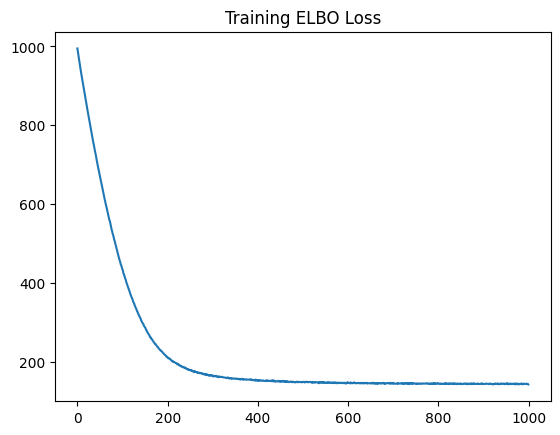

In [ ]:
plt.plot(losses)
plt.title("Training ELBO Loss")
plt.show()

In [ ]:
bnn.eval()
S = 500
samples = torch.zeros(len(dataset), S)
for j in range(S):
    samples[:,j] = bnn(design_matrix).view(-1)

In [ ]:
samples.mean(dim=1)

tensor([-0.4604,  0.1981,  0.3266,  ..., -0.2000,  0.2908, -0.5256],
       grad_fn=<MeanBackward1>)

In [ ]:
samples.std(dim=1)

tensor([1.0340, 1.1097, 1.1177,  ..., 1.1085, 1.1119, 1.0236],
       grad_fn=<StdBackward0>)

In [ ]:
riskset = time.view(-1, 1) <= time.repeat(len(time), 1)

In [ ]:
samples

tensor([[-5.3790e-01, -2.9393e-01, -4.1357e+00,  ..., -1.1794e+00,
         -4.0425e+00,  1.2406e-01],
        [ 5.7183e-01,  8.1503e-01, -4.1126e+00,  ..., -1.1792e+00,
         -4.0366e+00,  1.4785e+00],
        [ 5.7193e-01,  8.1503e-01, -3.1209e+00,  ..., -3.3593e-03,
         -2.9324e+00,  1.4785e+00],
        ...,
        [-5.3790e-01,  5.9672e-01, -3.0857e+00,  ..., -1.1524e+00,
         -4.0425e+00,  1.2406e-01],
        [-4.8192e-01,  8.1503e-01, -3.0393e+00,  ..., -1.1794e+00,
         -2.9171e+00,  1.3254e+00],
        [-5.3790e-01, -2.9393e-01, -4.1357e+00,  ..., -1.1794e+00,
         -4.0425e+00,  1.2406e-01]], grad_fn=<CopySlices>)

In [ ]:
W = torch.zeros_like(samples)
for j in range(S):
    W[:, j] = (riskset * torch.exp(samples[:,j].repeat(len(samples[:,j]), 1))).sum(dim=1)

In [ ]:
W

tensor([[ 537.3776,  735.5664, 1336.4398,  ...,  518.8325, 2108.3784,
         1941.3459],
        [ 435.9601,  574.9406, 1067.3275,  ...,  415.6849, 1702.8859,
         1576.1211],
        [ 520.8331,  709.9344, 1293.6462,  ...,  503.5403, 2045.7167,
         1883.2944],
        ...,
        [ 184.4219,  229.5034,  444.7725,  ...,  169.2618,  745.8173,
          658.0681],
        [ 785.9980, 1123.7462, 1968.4945,  ...,  768.8459, 3075.1572,
         2793.7878],
        [ 352.9775,  449.0926,  858.8251,  ...,  329.4702, 1389.8680,
         1269.8479]], grad_fn=<CopySlices>)

In [ ]:
Wm = W.mean(dim=1)
Wm


tensor([2197.9226, 1759.2445, 2129.7285,  ...,  731.2953, 3249.4224,
        1402.1791], grad_fn=<MeanBackward1>)

In [ ]:
xx = torch.tensor([1., 2., 3., 4.])
yy = torch.tensor([100., 200., 300., 400.])
yy0 = torch.tensor([200., 300.])
(xx * (yy <= yy0.view(-1, 1))).sum(dim=1)

tensor([3., 6.])

In [ ]:
cumhaz_0 = lambda t: (delta * (1/Wm) * (time < t.view(-1, 1))).sum(dim=1)

In [ ]:
cumhaz_0(torch.tensor([500, 1000, 1500, 2000]))

tensor([0.0622, 0.1716, 0.1837, 0.1837], grad_fn=<SumBackward1>)

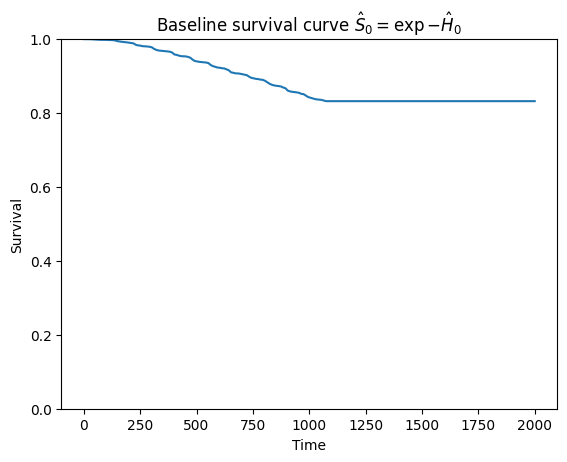

In [ ]:
tt = torch.linspace(0, 2000, 200)
surv = torch.exp(-cumhaz_0(tt))
plt.plot(tt.detach().numpy(), surv.detach().numpy())
plt.ylim((0, 1))
plt.xlabel('Time')
plt.ylabel('Survival')
plt.title(r'Baseline survival curve $\hat S_0=\exp{-\hat H_0}$')
plt.show()


In [ ]:
from lifelines.utils import concordance_index
concordance_index(time.detach().numpy(), -Wm.detach().numpy(), delta.detach().numpy())

np.float64(0.999694468868075)

tensor([-1.1686, -1.1675, -0.0035,  ..., -1.1186, -0.0034, -1.1686],
       grad_fn=<SelectBackward0>)

In [ ]:
samples

tensor([[-1.4980, -1.1686,  0.1319,  ..., -1.1920, -0.3029, -0.0128],
        [-0.3767, -1.1675,  0.2778,  ..., -0.3739,  0.9665,  1.0380],
        [-1.4850, -0.0035,  0.4676,  ..., -1.4522,  0.9665,  0.1718],
        ...,
        [-1.4980, -1.1186, -0.5673,  ..., -0.3742,  0.9665,  1.0373],
        [-0.3769, -0.0034,  0.4672,  ..., -0.3738,  0.5168, -0.0506],
        [-1.4980, -1.1686, -0.5801,  ..., -1.4631, -0.3029, -0.0506]],
       grad_fn=<CopySlices>)

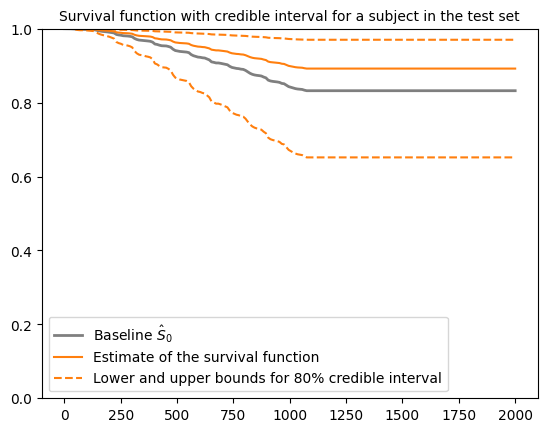

In [ ]:
tt_np = tt.detach().numpy()
surv_np = surv.detach().numpy()
pct10, pct50, pct90 = samples[0,:].quantile(torch.tensor([0.1, 0.5, 0.9]))
plt.plot(tt_np, surv_np, c='black', alpha=0.5, linewidth=2, label=r"Baseline $\hat S_0$")
plt.plot(tt_np, surv_np**np.exp(pct50.item()), c='tab:orange', label="Estimate of the survival function")
plt.plot(tt_np, surv_np**np.exp(pct10.item()), c='tab:orange', linestyle='--', 
         label="Lower and upper bounds for 80% credible interval")
plt.plot(tt_np, surv_np**np.exp(pct90.item()), c='tab:orange', linestyle='--')
plt.ylim(0., 1.)
plt.legend(loc='lower left')
plt.title('Survival function with credible interval for a subject in the test set', fontdict={'size': 10})
plt.show()


<!--bibtex

@Article{PER-GRA:2007,
  Author    = {P\'erez, Fernando and Granger, Brian E.},
  Title     = {{IP}ython: a System for Interactive Scientific Computing},
  Journal   = {Computing in Science and Engineering},
  Volume    = {9},
  Number    = {3},
  Pages     = {21--29},
  month     = may,
  year      = 2007,
  url       = "http://ipython.org",
  ISSN      = "1521-9615",
  doi       = {10.1109/MCSE.2007.53},
  publisher = {IEEE Computer Society},
}

@article{Papa2007,
  author = {Papa, David A. and Markov, Igor L.},
  journal = {Approximation algorithms and metaheuristics},
  pages = {1--38},
  title = {{Hypergraph partitioning and clustering}},
  url = {http://www.podload.org/pubs/book/part\_survey.pdf},
  year = {2007}
}

-->

<!--bibtex

@Article{PER-GRA:2007,
  Author    = {P\'erez, Fernando and Granger, Brian E.},
  Title     = {{IP}ython: a System for Interactive Scientific Computing},
  Journal   = {Computing in Science and Engineering},
  Volume    = {9},
  Number    = {3},
  Pages     = {21--29},
  month     = may,
  year      = 2007,
  url       = "http://ipython.org",
  ISSN      = "1521-9615",
  doi       = {10.1109/MCSE.2007.53},
  publisher = {IEEE Computer Society},
}

@article{Papa2007,
  author = {Papa, David A. and Markov, Igor L.},
  journal = {Approximation algorithms and metaheuristics},
  pages = {1--38},
  title = {{Hypergraph partitioning and clustering}},
  url = {http://www.podload.org/pubs/book/part\_survey.pdf},
  year = {2007}
}

-->